In [420]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/black-friday-sales-eda/train.csv


In [421]:
bfs = pd.read_csv('/kaggle/input/black-friday-sales-eda/train.csv')

In [422]:
import warnings
warnings.filterwarnings('ignore')

In [423]:
bfs.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969


In [424]:
bfs.columns

Index(['User_ID', 'Product_ID', 'Gender', 'Age', 'Occupation', 'City_Category',
       'Stay_In_Current_City_Years', 'Marital_Status', 'Product_Category_1',
       'Product_Category_2', 'Product_Category_3', 'Purchase'],
      dtype='object')

# Check basic statistics of dataset

In [425]:
bfs.shape

(550068, 12)

In [426]:
bfs.describe()

,User_ID,Occupation,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
count,5.500680e+05,550068.000000,550068.000000,550068.000000,376430.000000,166821.000000,550068.000000
mean,1.003029e+06,8.076707,0.409653,5.404270,9.842329,12.668243,9263.968713
std,1.727592e+03,6.522660,0.491770,3.936211,5.086590,4.125338,5023.065394
min,1.000001e+06,0.000000,0.000000,1.000000,2.000000,3.000000,12.000000
25%,1.001516e+06,2.000000,0.000000,1.000000,5.000000,9.000000,5823.000000
50%,1.003077e+06,7.000000,0.000000,5.000000,9.000000,14.000000,8047.000000
75%,1.004478e+06,14.000000,1.000000,8.000000,15.000000,16.000000,12054.000000
max,1.006040e+06,20.000000,1.000000,20.000000,18.000000,18.000000,23961.000000


In [427]:
bfs.dtypes

User_ID                         int64
Product_ID                     object
Gender                         object
Age                            object
Occupation                      int64
City_Category                  object
Stay_In_Current_City_Years     object
Marital_Status                  int64
Product_Category_1              int64
Product_Category_2            float64
Product_Category_3            float64
Purchase                        int64
dtype: object

# Check for missing values in the data



In [428]:
bfs.isnull().sum()

User_ID                            0
Product_ID                         0
Gender                             0
Age                                0
Occupation                         0
City_Category                      0
Stay_In_Current_City_Years         0
Marital_Status                     0
Product_Category_1                 0
Product_Category_2            173638
Product_Category_3            383247
Purchase                           0
dtype: int64

In [429]:
bfs['Product_Category_2'] = bfs['Product_Category_2'].fillna(0).astype(int)
bfs['Product_Category_3'] = bfs['Product_Category_3'].fillna(0).astype(int)

In [430]:
bfs['Product_Category_2'].isnull().sum()

0

In [431]:
bfs['Product_Category_3'].isnull().sum()

0

In [432]:
bfs.dtypes

User_ID                        int64
Product_ID                    object
Gender                        object
Age                           object
Occupation                     int64
City_Category                 object
Stay_In_Current_City_Years    object
Marital_Status                 int64
Product_Category_1             int64
Product_Category_2             int64
Product_Category_3             int64
Purchase                       int64
dtype: object

# check for unique values in data

In [433]:
bfs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   User_ID                     550068 non-null  int64 
 1   Product_ID                  550068 non-null  object
 2   Gender                      550068 non-null  object
 3   Age                         550068 non-null  object
 4   Occupation                  550068 non-null  int64 
 5   City_Category               550068 non-null  object
 6   Stay_In_Current_City_Years  550068 non-null  object
 7   Marital_Status              550068 non-null  int64 
 8   Product_Category_1          550068 non-null  int64 
 9   Product_Category_2          550068 non-null  int64 
 10  Product_Category_3          550068 non-null  int64 
 11  Purchase                    550068 non-null  int64 
dtypes: int64(7), object(5)
memory usage: 50.4+ MB


In [434]:
col = ['Gender','Age','City_Category','Stay_In_Current_City_Years','Marital_Status','Occupation',
        'Product_Category_1','Product_Category_2','Product_Category_3']
for c in col:
    print(bfs[c].unique())

['F' 'M']
['0-17' '55+' '26-35' '46-50' '51-55' '36-45' '18-25']
['A' 'C' 'B']
['2' '4+' '3' '1' '0']
[0 1]
[10 16 15  7 20  9  1 12 17  0  3  4 11  8 19  2 18  5 14 13  6]
[ 3  1 12  8  5  4  2  6 14 11 13 15  7 16 18 10 17  9 20 19]
[ 0  6 14  2  8 15 16 11  5  3  4 12  9 10 17 13  7 18]
[ 0 14 17  5  4 16 15  8  9 13  6 12  3 18 11 10]


In [435]:
bfs['Stay_In_Current_City_Years'] = bfs['Stay_In_Current_City_Years'].replace('4+','4').astype(int)

In [436]:
bfs['Stay_In_Current_City_Years'].unique()

array([2, 4, 3, 1, 0])

In [437]:
col = ['Gender','Age','City_Category','Stay_In_Current_City_Years','Marital_Status','Occupation',
        'Product_Category_1','Product_Category_2','Product_Category_3']
for c in col:
    print(bfs[c].unique())

['F' 'M']
['0-17' '55+' '26-35' '46-50' '51-55' '36-45' '18-25']
['A' 'C' 'B']
[2 4 3 1 0]
[0 1]
[10 16 15  7 20  9  1 12 17  0  3  4 11  8 19  2 18  5 14 13  6]
[ 3  1 12  8  5  4  2  6 14 11 13 15  7 16 18 10 17  9 20 19]
[ 0  6 14  2  8 15 16 11  5  3  4 12  9 10 17 13  7 18]
[ 0 14 17  5  4 16 15  8  9 13  6 12  3 18 11 10]


In [438]:
bfs.dtypes

User_ID                        int64
Product_ID                    object
Gender                        object
Age                           object
Occupation                     int64
City_Category                 object
Stay_In_Current_City_Years     int64
Marital_Status                 int64
Product_Category_1             int64
Product_Category_2             int64
Product_Category_3             int64
Purchase                       int64
dtype: object

# Purchase Distribution

In [439]:
import matplotlib.pyplot as plt
import seaborn as sns

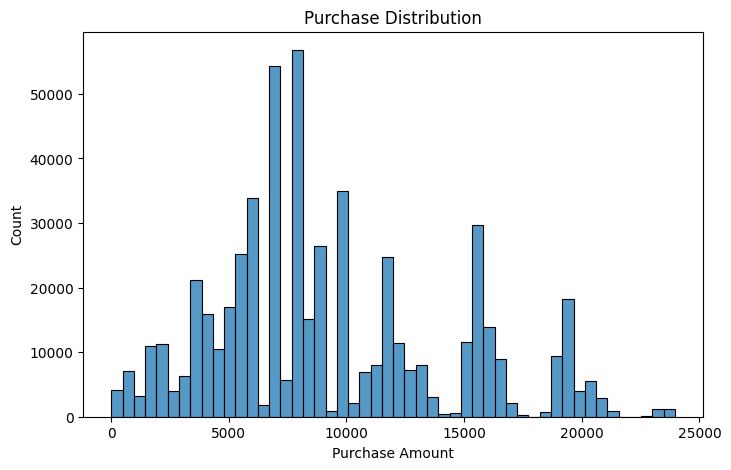

In [440]:
plt.figure(figsize=(8,5))
sns.histplot(bfs['Purchase'], bins=50)
plt.title('Purchase Distribution')
plt.xlabel('Purchase Amount')
plt.ylabel('Count')
plt.show()

Most customers buy items costing ₹5,000 to ₹10,000 However, a lot of other customers also make large purchases in the ₹12,000, ₹15,000, and ₹18,000 to ₹20,000 price ranges.

# check for outliers

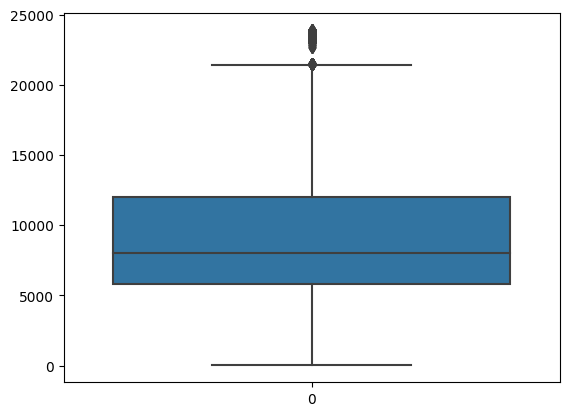

In [441]:
sns.boxplot(bfs['Purchase'])
plt.show()

 Most customers spend between ₹5,000 and ₹13,000

In [442]:
bfs.columns

Index(['User_ID', 'Product_ID', 'Gender', 'Age', 'Occupation', 'City_Category',
       'Stay_In_Current_City_Years', 'Marital_Status', 'Product_Category_1',
       'Product_Category_2', 'Product_Category_3', 'Purchase'],
      dtype='object')

# Rename Columns

In [443]:
bfs.rename(columns={
    'User_ID':'UID',
    'Product_ID':'PID',
    'Stay_In_Current_City_Years':'years_in_city',
    'Product_Category_1':'Product_Cat_1',
    'Product_Category_2':'Product_Cat_2',
    'Product_Category_3':'Product_Cat_3',
    'Purchase':'Purchase_Amount'   
},inplace=True)

# Convert categorical data into integer using map function (e.g 'Gender','Age' column)



In [444]:
bfs.dtypes

UID                 int64
PID                object
Gender             object
Age                object
Occupation          int64
City_Category      object
years_in_city       int64
Marital_Status      int64
Product_Cat_1       int64
Product_Cat_2       int64
Product_Cat_3       int64
Purchase_Amount     int64
dtype: object

In [445]:
bfs['Gender'] = bfs['Gender'].map({'M':1,'F':0})

In [446]:
bfs['Gender']

0         0
1         0
2         0
3         0
4         1
         ..
550063    1
550064    0
550065    0
550066    0
550067    0
Name: Gender, Length: 550068, dtype: int64

In [447]:
bfs['Age'].unique()

array(['0-17', '55+', '26-35', '46-50', '51-55', '36-45', '18-25'],
      dtype=object)

| Original | Suggested Name  |
| -------- | --------------- |
| `0-17`   | `teenagers`     |
| `18-25`  | `young_adults`  |
| `26-35`  | `early_adults`  |
| `36-45`  | `mid_adults`    |
| `46-50`  | `late_adults`   |
| `51-55`  | `mature_adults` |
| `55+`    | `seniors`       |


In [448]:
bfs['Age'] = bfs['Age'].map({
    '0-17':'Teenagers',
    '18-25':'Young_Adults',
    '26-35':'Early_Adults',
    '36-45':'Mid_Adults',
    '46-50':'Late_Adults',
    '51-55':'Mature_Adults',
    '55+':'Seniors'
})

In [449]:
bfs['Age']

0             Teenagers
1             Teenagers
2             Teenagers
3             Teenagers
4               Seniors
              ...      
550063    Mature_Adults
550064     Early_Adults
550065     Early_Adults
550066          Seniors
550067      Late_Adults
Name: Age, Length: 550068, dtype: object

# visualize individul column


In [450]:
bfs.columns

Index(['UID', 'PID', 'Gender', 'Age', 'Occupation', 'City_Category',
       'years_in_city', 'Marital_Status', 'Product_Cat_1', 'Product_Cat_2',
       'Product_Cat_3', 'Purchase_Amount'],
      dtype='object')

In [451]:
bfs.dtypes

UID                 int64
PID                object
Gender              int64
Age                object
Occupation          int64
City_Category      object
years_in_city       int64
Marital_Status      int64
Product_Cat_1       int64
Product_Cat_2       int64
Product_Cat_3       int64
Purchase_Amount     int64
dtype: object

# Gender vs Purchase_Amount

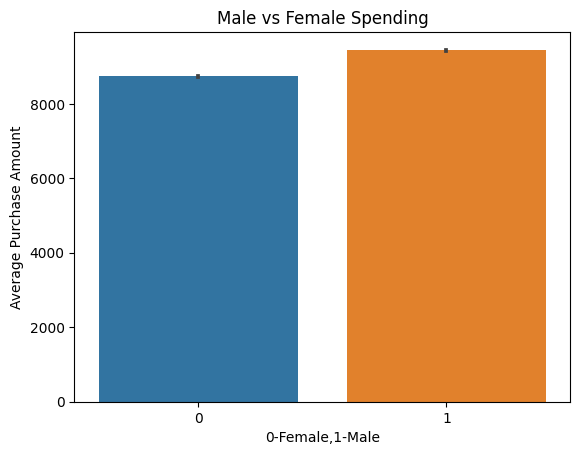

In [452]:
sns.barplot(x='Gender',y='Purchase_Amount',data=bfs)
plt.xlabel("0-Female,1-Male")
plt.ylabel('Average Purchase Amount')
plt.title('Male vs Female Spending')
plt.show()

On average, male customers spend more than female customers.

# Marital_Status vs Purchase_Amount

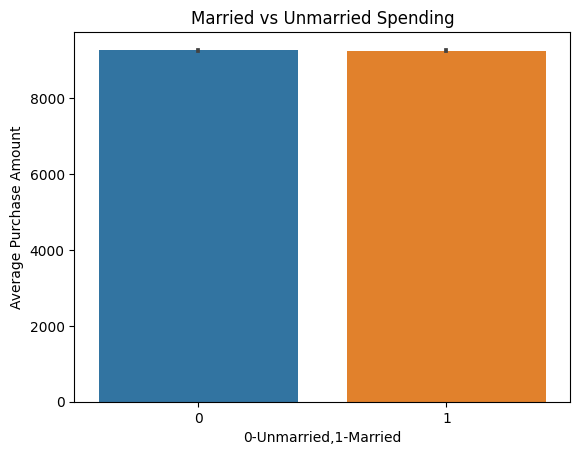

In [453]:
sns.barplot(x='Marital_Status',y='Purchase_Amount',data=bfs)
plt.xlabel("0-Unmarried,1-Married")
plt.ylabel('Average Purchase Amount')
plt.title('Married vs Unmarried Spending')
plt.show()

On average, married and unmarried customers spend almost the same amount.


# Occupation vs Purchase_Amount

In [454]:
# 1. Find the average purchase by each occupation
avg_purchase = bfs.groupby('Occupation')['Purchase_Amount'].mean().sort_values(ascending=False)
print(avg_purchase)

Occupation
17    9821.478236
12    9796.640239
15    9778.891163
8     9532.592497
14    9500.702772
7     9425.728223
16    9394.464349
5     9333.149298
13    9306.351061
6     9256.535691
4     9213.980251
11    9213.845848
3     9178.593088
18    9169.655844
0     9124.428588
10    8959.355375
1     8953.193270
2     8952.481683
20    8836.494905
19    8710.627231
9     8637.743761
Name: Purchase_Amount, dtype: float64


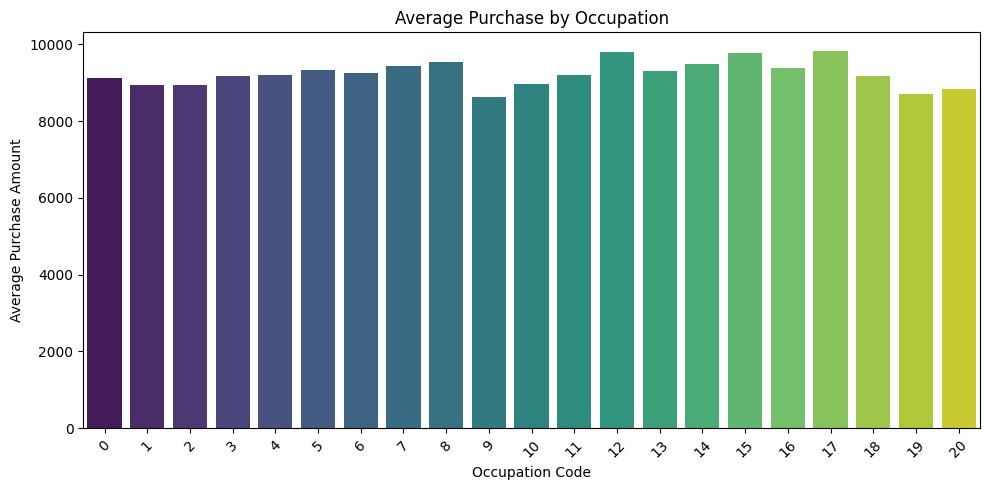

In [455]:
# 2. Plot the averages in the same sorted order
plt.figure(figsize=(10,5))
sns.barplot(
    x=avg_purchase.index, 
    y=avg_purchase.values, 
    palette='viridis'
)

plt.xlabel("Occupation Code")
plt.ylabel("Average Purchase Amount")
plt.title("Average Purchase by Occupation")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Customers in occupation codes 17, 12, and 15 have the highest average spending, whereas those in codes 19 and 9 spend the least.

In [456]:
bfs.dtypes

UID                 int64
PID                object
Gender              int64
Age                object
Occupation          int64
City_Category      object
years_in_city       int64
Marital_Status      int64
Product_Cat_1       int64
Product_Cat_2       int64
Product_Cat_3       int64
Purchase_Amount     int64
dtype: object

# City vs Purchase_Amount

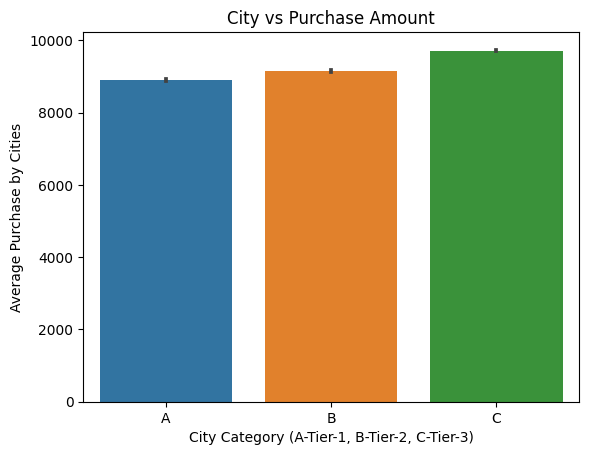

In [457]:
sns.barplot(x='City_Category', y='Purchase_Amount',order=['A','B','C'], data=bfs)
plt.title('City vs Purchase Amount')
plt.xlabel('City Category (A-Tier-1, B-Tier-2, C-Tier-3)')
plt.ylabel('Average Purchase by Cities')
plt.show()

Customers from C spend more on average than those A or B cities.

# Product_category_1 vs Purchase_Amount


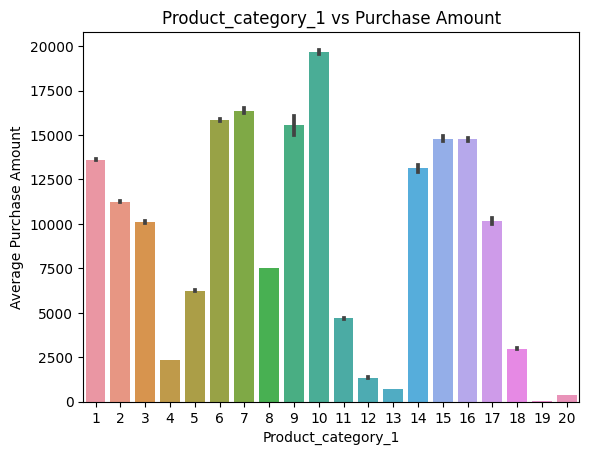

In [458]:
sns.barplot(x='Product_Cat_1', y='Purchase_Amount', data=bfs)
plt.title('Product_category_1 vs Purchase Amount')
plt.xlabel('Product_category_1')
plt.ylabel('Average Purchase Amount')
plt.show()

Product category 10 has the highest average purchase.

# Product_category_2 vs Purchase_Amount

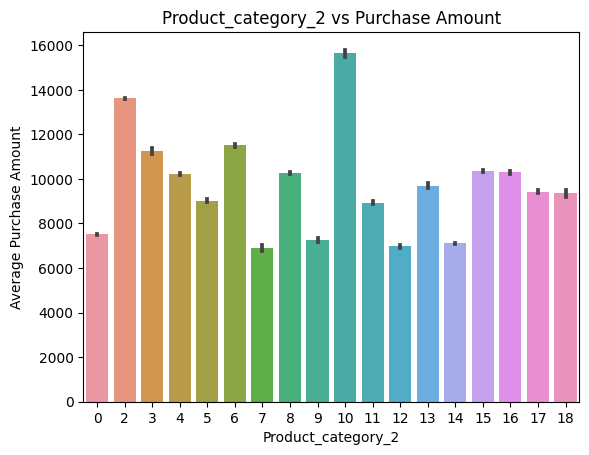

In [459]:
sns.barplot(x='Product_Cat_2', y='Purchase_Amount', data=bfs)
plt.title('Product_category_2 vs Purchase Amount')
plt.xlabel('Product_category_2')
plt.ylabel('Average Purchase Amount')
plt.show()

Product category 10 has the highest average purchase.

# Product_category_3 vs Purchase_Amount

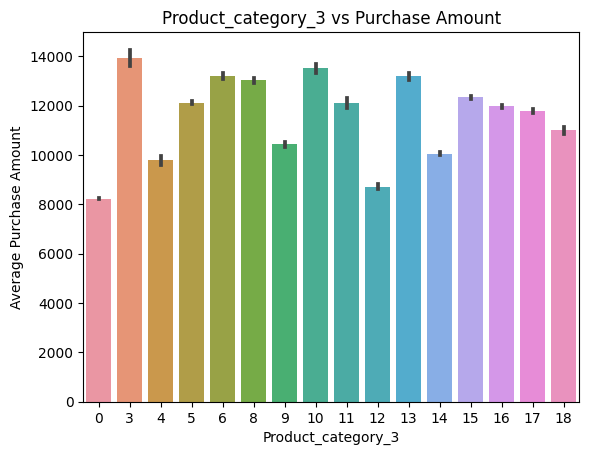

In [460]:
sns.barplot(x='Product_Cat_3', y='Purchase_Amount', data=bfs)
plt.title('Product_category_3 vs Purchase Amount')
plt.xlabel('Product_category_3')
plt.ylabel('Average Purchase Amount')
plt.show()

Product category 3 has the highest average purchase.